# Bayesian Inference — Root Cause Attribution

Given that something went wrong, which source is most likely responsible?

This notebook applies Bayes' Theorem to a multi-source attribution problem: a defective part is found in a warehouse supplied by three vendors. Using prior knowledge of supply shares and defect rates, we work backwards to identify the most probable origin.

**Setup:**

| Supplier | Market Share | Defect Rate |
|----------|-------------|-------------|
| A        | 25%         | 10%         |
| B        | 35%         | 6%          |
| C        | 40%         | 7%          |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Bayesian Attribution

The posterior probability that a defective part came from supplier X is:

$$P(X | defective) = \frac{P(defective | X) \cdot P(X)}{\sum_{i} P(defective | i) \cdot P(i)}$$

The denominator is the **law of total probability** — the overall rate of defective parts across all suppliers. It normalises the posteriors so they sum to 1.

In [2]:
suppliers    = ['A', 'B', 'C']
shares       = np.array([0.25, 0.35, 0.40])  # prior: P(supplier)
defect_rates = np.array([0.10, 0.06, 0.07])  # likelihood: P(defective | supplier)

# Total probability of a defective part (law of total probability)
p_defective = np.sum(defect_rates * shares)

# Posterior: P(supplier | defective)
posteriors = (defect_rates * shares) / p_defective

print(f"Overall defect rate in warehouse: {p_defective:.4f} ({p_defective*100:.2f}%)\n")
for s, prior, post in zip(suppliers, shares, posteriors):
    print(f"Supplier {s}:  prior = {prior:.0%}  →  posterior = {post:.4f} ({post*100:.1f}%)")

Overall defect rate in warehouse: 0.0740 (7.40%)

Supplier A:  prior = 25%  →  posterior = 0.3378 (33.8%)
Supplier B:  prior = 35%  →  posterior = 0.2838 (28.4%)
Supplier C:  prior = 40%  →  posterior = 0.3784 (37.8%)


## Visualisation — Prior vs Posterior

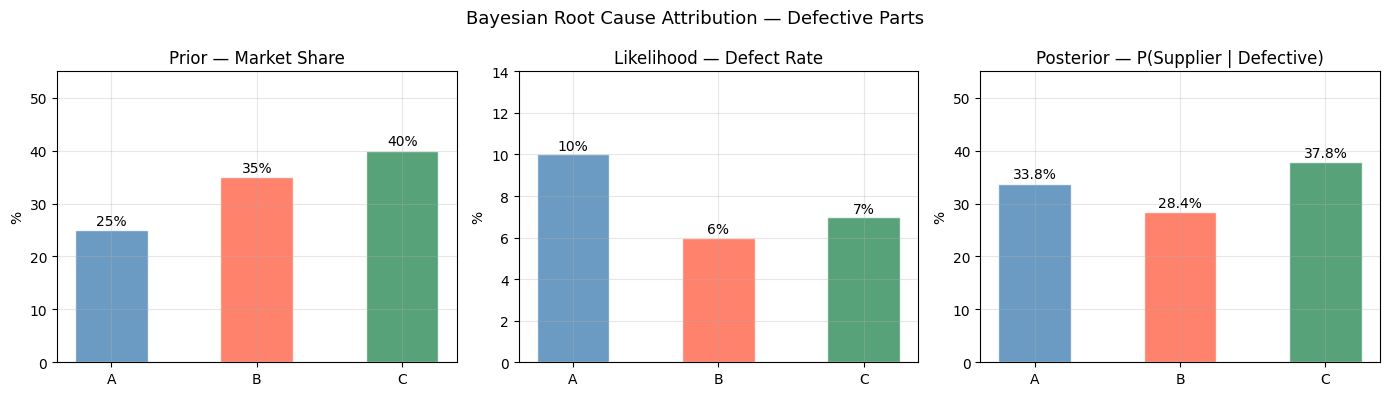

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['steelblue', 'tomato', 'seagreen']

# Prior: market share
axes[0].bar(suppliers, shares * 100, color=colors, alpha=0.8, edgecolor='white', width=0.5)
axes[0].set_title('Prior — Market Share')
axes[0].set_ylabel('%')
axes[0].set_ylim(0, 55)
for i, v in enumerate(shares):
    axes[0].text(i, v*100 + 1, f'{v:.0%}', ha='center', fontsize=10)

# Likelihood: defect rates
axes[1].bar(suppliers, defect_rates * 100, color=colors, alpha=0.8, edgecolor='white', width=0.5)
axes[1].set_title('Likelihood — Defect Rate')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 14)
for i, v in enumerate(defect_rates):
    axes[1].text(i, v*100 + 0.2, f'{v:.0%}', ha='center', fontsize=10)

# Posterior: probability of being the source given defective
axes[2].bar(suppliers, posteriors * 100, color=colors, alpha=0.8, edgecolor='white', width=0.5)
axes[2].set_title('Posterior — P(Supplier | Defective)')
axes[2].set_ylabel('%')
axes[2].set_ylim(0, 55)
for i, v in enumerate(posteriors):
    axes[2].text(i, v*100 + 1, f'{v:.1%}', ha='center', fontsize=10)

plt.suptitle('Bayesian Root Cause Attribution — Defective Parts', fontsize=13)
plt.tight_layout()
plt.savefig('bayesian_root_cause_attribution.png', dpi=150)
plt.show()

## Monte Carlo Verification

We can verify the analytical result by simulating a large warehouse and sampling defective parts.

In [4]:
np.random.seed(42)
N = 1_000_000  # simulate 1 million parts

# Assign each part to a supplier based on market share
supplier_ids = np.random.choice([0, 1, 2], size=N, p=shares)

# Each part is defective with its supplier's defect rate
defect_probs = defect_rates[supplier_ids]
is_defective = np.random.uniform(0, 1, N) < defect_probs

# Among defective parts, count by supplier
defective_supplier_ids = supplier_ids[is_defective]
mc_posteriors = np.array([(defective_supplier_ids == i).sum() for i in range(3)]) / is_defective.sum()

print("Analytical vs Monte Carlo posteriors:\n")
for s, analytical, mc in zip(suppliers, posteriors, mc_posteriors):
    print(f"Supplier {s}:  analytical = {analytical:.4f}   MC = {mc:.4f}")

Analytical vs Monte Carlo posteriors:

Supplier A:  analytical = 0.3378   MC = 0.3370
Supplier B:  analytical = 0.2838   MC = 0.2820
Supplier C:  analytical = 0.3784   MC = 0.3810


**Key insight:** Supplier A has the highest defect rate (10%) but delivers only 25% of parts. Despite this, it is responsible for ~34% of all defective units — disproportionate to its share. Supplier C delivers the most parts (40%) but its moderate defect rate means it contributes proportionally less than A to the defect pool.

**Real-world connection:** This pattern appears directly in **anomaly detection and root cause analysis** in data engineering and MLOps. Given a system failure — a crashed pipeline, a model performance drop, a spike in errors — the question is always the same: which upstream source is most likely responsible? Bayesian attribution gives a principled, quantitative answer by combining prior knowledge (how often does each component fail?) with observed evidence (a failure occurred). The same framework is used in network fault diagnosis, microservice observability, and manufacturing quality control.